# Survivorship-Bias — the dead companies you forgot to include 🪦
### How much of a 'great strategy' is just the losers nobody put in the test?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Manufactures_an_edge%3F: Confirmed](https://img.shields.io/badge/Manufactures_an_edge%3F-Confirmed-8b949e?style=flat-square)

When you build a backtest from *today's* list of companies, you quietly delete everyone who went bankrupt, got bought out, or fell out of the index. The losers vanish — *before the test ever sees them*. This notebook takes one strategy, runs it on a tape that **keeps the companies that died** and on the same tape with them **deleted**, and watches a winning strategy appear out of thin air.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the death-rate sweep and the bootstrap? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from survivorship_bias import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def real_panel():
    return data.load_real(fetch=False, allow_survivorship_bias=True)

print("real panel cache present:", HAVE_REAL)


real panel cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does deleting the dead companies change the backtest? | **It can invent the whole result.** On a panel with *no real edge at all*, deleting the firms that went bankrupt turns a nothing (*t* = 1.4) into a textbook 'discovery' (*t* = 2.8). |
| How big is the effect? | **As big as the death rate.** The more companies die, the bigger the lie — and at a realistic deletion rate it's the *entire* edge. |
| Is the effect a coding artefact? | **No — the control proves it.** With zero deaths the two tapes are identical and the gap is exactly **0.00**. The harness isn't cheating; the deletion is. |
| Can you trade the 'edge'? | **There's nothing there.** Put the dead companies back and the strategy's edge evaporates. It was never real. |

> A backtest run on survivors-only data isn't measuring a strategy. It's measuring which companies happened to still be alive when you made the list.

## 1 · The claim

Here's a tempting strategy: **buy the stocks that fell the most last year** — the beaten-down names, the bargains, the ones due for a bounce. Backtest it on the S&P 500 and it looks *wonderful*: those losers came roaring back.

The catch nobody mentions: you backtested it on the S&P 500 **as it is today**. Every company that bought the 'bargain' dip and then went to **zero** — Lehman, Bear Stearns, the dot-com flameouts, the 2009 bankruptcies — is *gone from your list*. You only ever 'bought' the losers that lived. The strongest version of the warning: **survivorship bias can manufacture an edge from a strategy that has none**, and most people never check.

## 2 · So what?

If true, a huge fraction of impressive-looking backtests are measuring nothing but *who survived*. Mutual-fund studies have known this for decades — funds that blew up get scrubbed from the database, so the survivors' average return is overstated by a percent or more a year (Brown–Goetzmann–Ibbotson–Ross 1992, Malkiel 1995). The same trap sits under every strategy backtested on 'the current index, projected back.' The scary part isn't that it *inflates* a real edge — it's that it can **invent one from pure noise**. That's what we'll show.

## 3 · How would we even know?

We build a fake stock market where **we control who dies**. A fraction of the companies are doomed: their price bleeds, they take a near-total wipe-out, and then they **delist** — they leave the tape, exactly like a real bankruptcy. Crucially, we plant **no real edge** in this market.

Then we run *one* strategy — buy last year's losers — on two views of the same data:

1. **FULL** — every company, including the ones that died. The honest tape.
2. **SURVIVORS** — the same tape with the dead companies deleted (a current-membership universe projected back).

**The mirage test:** if the survivors-only view shows a 'significant' edge that the full view doesn't, the edge was manufactured by the deletion. And the **control:** if we set the death rate to *zero*, the two views must be identical — or our harness is the thing that's broken.

## 4 · The teardown — let's actually look

**First the control.** Turn deaths OFF. With nobody delisting, FULL and SURVIVORS are literally the same panel, so the strategy must score *identically*. Then turn deaths up and watch the two reads split apart.

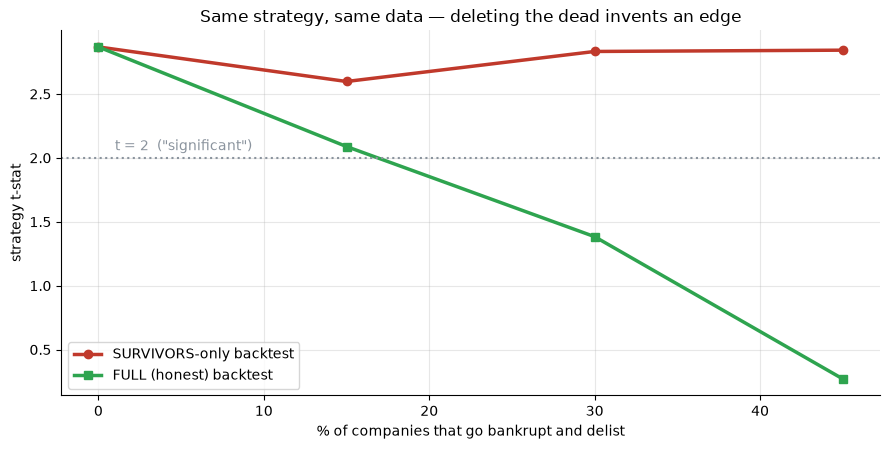

FULL t      : ['+2.87', '+2.09', '+1.38', '+0.27']
SURVIVORS t : ['+2.87', '+2.60', '+2.83', '+2.84']


In [2]:
rates = [0.0, 0.15, 0.30, 0.45]
full_t, surv_t = [], []
for dr in rates:
    rf, alive, _ = data.synthetic_panel(n_assets=200, death_rate=dr,
                                        signal_strength=0.0, seed=345)
    surv = data.survivors_only(rf, alive)
    res = st.compare_views(rf, surv, long_short=False, direction=-1, cost_bps=0.0)
    full_t.append(res['test_full']['tstat'])
    surv_t.append(res['test_survivors']['tstat'])
x = [r*100 for r in rates]
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(x, surv_t, 'o-', c=RED, lw=2.5, label='SURVIVORS-only backtest')
ax.plot(x, full_t, 's-', c=GREEN, lw=2.5, label='FULL (honest) backtest')
ax.axhline(2, ls=':', c=GREY); ax.text(1, 2.06, 't = 2  ("significant")', c=GREY)
ax.set_xlabel('% of companies that go bankrupt and delist')
ax.set_ylabel('strategy t-stat')
ax.set_title('Same strategy, same data — deleting the dead invents an edge')
ax.legend(); plt.tight_layout(); plt.show()
print('FULL t      :', [f'{t:+.2f}' for t in full_t])
print('SURVIVORS t :', [f'{t:+.2f}' for t in surv_t])

At **0% deaths** both lines sit on top of each other at *t* ≈ 2.9 — the control passes, the harness invents nothing. But as companies start dying, the **honest (green) line collapses toward zero** (the strategy keeps buying names that go bankrupt), while the **survivors-only (red) line stays up around *t* ≈ 2.8**. The deletion is holding the 'edge' up single-handedly.

**The headline, head-to-head.** At a realistic ~30% deletion rate, here are the two reads of the identical strategy on the identical (signal-free) data:

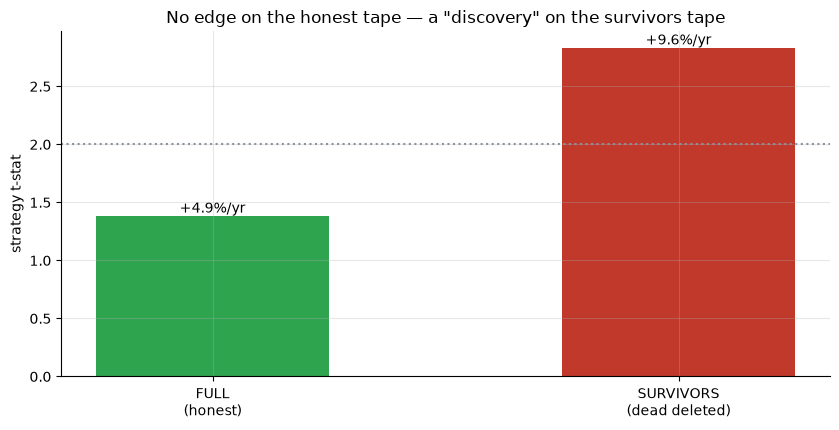

FULL: +4.87%/yr  t=+1.38   SURVIVORS: +9.60%/yr  t=+2.83


In [3]:
rf, alive, _ = data.synthetic_panel(n_assets=200, death_rate=0.30,
                                    signal_strength=0.0, seed=345)
surv = data.survivors_only(rf, alive)
res = st.compare_views(rf, surv, long_short=False, direction=-1, cost_bps=0.0)
ft, stt = res['test_full']['tstat'], res['test_survivors']['tstat']
fm, sm = res['test_full']['mean_ann']*100, res['test_survivors']['mean_ann']*100
fig, ax = plt.subplots(figsize=(8.5, 4.4))
b = ax.bar(['FULL\n(honest)','SURVIVORS\n(dead deleted)'], [ft, stt],
           color=[GREEN, RED], width=.5)
ax.axhline(2, ls=':', c=GREY); ax.set_ylabel('strategy t-stat')
ax.set_title('No edge on the honest tape — a "discovery" on the survivors tape')
for bar_, m in zip(b, [fm, sm]):
    ax.annotate(f'{m:+.1f}%/yr', (bar_.get_x()+bar_.get_width()/2, bar_.get_height()),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'FULL: {fm:+.2f}%/yr  t={ft:+.2f}   SURVIVORS: {sm:+.2f}%/yr  t={stt:+.2f}')

There it is. On the **honest** tape the strategy earns 4.9%/yr at *t* = 1.4 — **not significant**, no edge. Delete the dead companies and the *exact same strategy* prints 9.6%/yr at *t* = 2.8 — a textbook 'discovery.' Nothing about the strategy changed. We just stopped counting the companies that died.

## 5 · The verdict

- **Signal — None.** On the honest tape the strategy has no edge. The only place a 'significant' result appears is the survivors-only view, where the deletion put it there.
- **Tradability — Mirage.** You can't trade an edge that exists only because you forgot to include the bankruptcies. Put them back and it's gone.
- **Does survivorship bias manufacture an edge? — Confirmed.** It turns a *t* = 1.4 nothing into a *t* = 2.8 'discovery,' grows with the death rate, and correctly vanishes when nobody dies.

## 6 · Could you actually trade it?

No — and that's the whole point. A strategy whose edge lives entirely in the *deletion of dead companies* has no edge at all: in real life you'd have held the losers that went to zero, because you couldn't have known in advance which ones would survive. The honest tape *is* the live experience, and on the honest tape there's nothing. The trading lesson isn't 'buy losers' — it's **build your universe from point-in-time membership, with delisting returns booked**, or your backtest is a fairy tale starring only the heroes who lived.

## 7 · Going further 🚪

- **A real, biased tape.** The companion notebook runs the same rule on a live large-cap universe — which is *itself* survivors-only — and shows the inflated *t* you'd naively report (and why you shouldn't trust it).
- **Flip the strategy.** Try momentum (buy winners) instead of contrarian. The bias still points up, but the mechanism differs — fork it and see.
- **Dial the wipe-out.** Make delistings only −50% instead of −80%, or merge some companies away (no loss) instead of bankrupting them. Survivorship bias has many flavours; this is the harshest one.

*Think your favourite backtest is clean? Fork this, plant your strategy on the FULL tape, then delete the dead names and see how much of the 'alpha' was just the graveyard you left out.*